# IRT Analysis of LLM Benchmarks — Fantastic-Bugs Dataset

**CS321M Course Project — AI Measurement Science**

This notebook applies Item Response Theory (IRT) models to LLM benchmark response matrices
from the [fantastic-bugs](https://huggingface.co/datasets/stair-lab/fantastic-bugs) dataset.

**Benchmarks analyzed:** GSM8K, MedQA, OpenBookQA, BoolQ, MMLU-Math, LegalBench

**Models fit:** Rasch (1PL), 2PL, LogisticFM (K=1,2,4)

**Key questions:**
1. How does psychometric structure differ across LLM benchmarks?
2. Which benchmarks have high item discrimination vs. uniform difficulty?
3. Can IRT ability (θ) predict model scale (log params)?

In [2]:
# Clean up any stale torch_measure and torch_geometric imports from previous runs
import importlib, sys

# Clear torch_measure cache (repo folder shadows installed package)
mods_to_remove = [k for k in sys.modules if k.startswith("torch_measure")]
for k in mods_to_remove:
    del sys.modules[k]

# Clear torch_geometric sampler cache so it re-detects pyg-lib/torch-sparse
for prefix in ("pyg_lib", "torch_sparse", "torch_scatter", "torch_cluster",
               "torch_geometric.sampler", "torch_geometric.loader"):
    stale = [k for k in sys.modules if k.startswith(prefix)]
    for k in stale:
        del sys.modules[k]
        
print(f"Cleared {len(mods_to_remove)} stale modules. Verifying pyg-lib...")
try:
    import pyg_lib
    print(f"  pyg_lib OK: {pyg_lib.__file__}")
except (ImportError, RuntimeError) as e:
    print(f"  pyg_lib issue: {e}")
try:
    import torch_sparse
    print(f"  torch_sparse OK: {torch_sparse.__file__}")
except (ImportError, RuntimeError) as e:
    print(f"  torch_sparse issue (non-fatal for GNN): {e}")

Cleared 79 stale modules. Verifying pyg-lib...
  pyg_lib OK: /home/azureuser/gpt4hana-base/.venv/lib/python3.11/site-packages/pyg_lib/__init__.py
  torch_sparse OK: /home/azureuser/gpt4hana-base/.venv/lib/python3.11/site-packages/torch_sparse/__init__.py
  torch_sparse OK: /home/azureuser/gpt4hana-base/.venv/lib/python3.11/site-packages/torch_sparse/__init__.py


In [3]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from huggingface_hub import hf_hub_download, list_repo_files

# torch_measure for IRT fitting
import torch
import torch_measure

print(f"torch_measure version: {torch_measure.__version__}")
print(f"torch version: {torch.__version__}")

sns.set_theme(style='whitegrid', font_scale=1.2)
%matplotlib inline

/home/azureuser/gpt4hana-base/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch_measure version: 0.1.dev38+gb2fd9d99a
torch version: 2.10.0+cu128


## 1. Download Fantastic-Bugs Data from HuggingFace

In [4]:
# List all files in the dataset repo
repo_id = "stair-lab/fantastic-bugs"
files = list_repo_files(repo_id, repo_type="dataset")
for f in sorted(files):
    print(f)

.gitattributes
README.md
data/airbench-00000-of-00001.parquet
data/gsm-00000-of-00001.parquet
data/med_qa-00000-of-00001.parquet
data/mmlu_5subject-00000-of-00001.parquet
data/mmlu_clinical_knowledge-00000-of-00001.parquet
data/mmlu_math-00000-of-00001.parquet
data/mmlu_professional_medicine-00000-of-00001.parquet
data/openbookqa-00000-of-00001.parquet
data/thaiexam-00000-of-00001.parquet
raw/air-bench_air-bench_2024_results.pkl
raw/classic_bbq_results.pkl
raw/classic_boolq_results.pkl
raw/classic_wikifact_results.pkl
raw/library.tar.gz
raw/lite_commonsense_results.pkl
raw/lite_gsm_results_enhanced.pkl
raw/lite_legalbench_results.pkl
raw/lite_med_qa_results.pkl
raw/lite_mmlu_results.pkl
raw/long.pkl
raw/mmlu_mmlu_clinical_knowledge_results.pkl
raw/mmlu_mmlu_results_enhanced.pkl
raw/mmlu_mmluprofessional_medicine_results.pkl
raw/model_info.csv
raw/syn_2pl_irt_data.pkl
raw/syn_testtaker_num_data.pkl
raw/thaiexam_thai_exam_results.pkl


In [5]:
# Download only the raw result files (skip library.tar.gz which is ~40GB)
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

SKIP = {"README.md", "raw/library.tar.gz", "raw/long.pkl"}

for f in sorted(files):
    if f.startswith(".") or f in SKIP:
        continue
    # Only download raw/ pkl/csv files and skip large parquet duplicates
    if not f.startswith("raw/"):
        continue
    local_path = hf_hub_download(repo_id, f, repo_type="dataset", local_dir=str(data_dir))
    print(f"Downloaded: {f}")

# Show what we have
for p in sorted(data_dir.rglob("*")):
    if p.is_file():
        print(f"  {p.relative_to(data_dir)}")

Downloaded: raw/air-bench_air-bench_2024_results.pkl
Downloaded: raw/classic_bbq_results.pkl
Downloaded: raw/classic_boolq_results.pkl
Downloaded: raw/classic_wikifact_results.pkl
Downloaded: raw/classic_boolq_results.pkl
Downloaded: raw/classic_wikifact_results.pkl
Downloaded: raw/lite_commonsense_results.pkl
Downloaded: raw/lite_gsm_results_enhanced.pkl
Downloaded: raw/lite_commonsense_results.pkl
Downloaded: raw/lite_gsm_results_enhanced.pkl
Downloaded: raw/lite_legalbench_results.pkl
Downloaded: raw/lite_med_qa_results.pkl
Downloaded: raw/lite_legalbench_results.pkl
Downloaded: raw/lite_med_qa_results.pkl
Downloaded: raw/lite_mmlu_results.pkl
Downloaded: raw/mmlu_mmlu_clinical_knowledge_results.pkl
Downloaded: raw/lite_mmlu_results.pkl
Downloaded: raw/mmlu_mmlu_clinical_knowledge_results.pkl
Downloaded: raw/mmlu_mmlu_results_enhanced.pkl
Downloaded: raw/mmlu_mmluprofessional_medicine_results.pkl
Downloaded: raw/mmlu_mmlu_results_enhanced.pkl
Downloaded: raw/mmlu_mmluprofessional_me

## 2. Load and Explore Response Matrices

In [6]:
# Discover available benchmarks by looking for *_results.pkl files
result_files = sorted(data_dir.rglob("*_results.pkl"))
print(f"Found {len(result_files)} benchmark result files:\n")
for f in result_files:
    print(f"  {f.relative_to(data_dir)}")

Found 11 benchmark result files:

  raw/air-bench_air-bench_2024_results.pkl
  raw/classic_bbq_results.pkl
  raw/classic_boolq_results.pkl
  raw/classic_wikifact_results.pkl
  raw/lite_commonsense_results.pkl
  raw/lite_legalbench_results.pkl
  raw/lite_med_qa_results.pkl
  raw/lite_mmlu_results.pkl
  raw/mmlu_mmlu_clinical_knowledge_results.pkl
  raw/mmlu_mmluprofessional_medicine_results.pkl
  raw/thaiexam_thai_exam_results.pkl


In [7]:
# Load all response matrices
benchmarks = {}

for f in result_files:
    name = f.stem.replace("_results", "")
    with open(f, "rb") as fh:
        data = pickle.load(fh)
    
    # Inspect what we got
    if isinstance(data, pd.DataFrame):
        mat = data.values
        model_names = list(data.index)
        item_names = list(data.columns)
    elif isinstance(data, np.ndarray):
        mat = data
        model_names = [f"model_{i}" for i in range(mat.shape[0])]
        item_names = [f"item_{j}" for j in range(mat.shape[1])]
    elif isinstance(data, dict):
        print(f"  {name}: dict with keys {list(data.keys())[:10]}")
        # Try common patterns
        if 'response_matrix' in data:
            mat = data['response_matrix']
        elif 'results' in data:
            mat = data['results']
        else:
            mat = data
        if isinstance(mat, pd.DataFrame):
            model_names = list(mat.index)
            item_names = list(mat.columns)
            mat = mat.values
        else:
            model_names = [f"model_{i}" for i in range(mat.shape[0])]
            item_names = [f"item_{j}" for j in range(mat.shape[1])]
    else:
        print(f"  {name}: unknown type {type(data)}")
        continue
    
    benchmarks[name] = {
        'matrix': np.array(mat, dtype=float),
        'model_names': model_names,
        'item_names': item_names,
        'raw': data
    }
    print(f"  {name}: {mat.shape[0]} models × {mat.shape[1]} items, "
          f"mean accuracy = {np.nanmean(mat):.3f}")

print(f"\nLoaded {len(benchmarks)} benchmarks")

  air-bench_air-bench_2024: 41 models × 5693 items, mean accuracy = 0.552
  classic_bbq: 42 models × 1000 items, mean accuracy = 0.413
  classic_boolq: 67 models × 3316 items, mean accuracy = 0.716
  classic_wikifact: 67 models × 5512 items, mean accuracy = 0.341
  classic_boolq: 67 models × 3316 items, mean accuracy = 0.716
  classic_wikifact: 67 models × 5512 items, mean accuracy = 0.341
  lite_commonsense: 91 models × 500 items, mean accuracy = 0.831
  lite_legalbench: 91 models × 1997 items, mean accuracy = 0.553
  lite_commonsense: 91 models × 500 items, mean accuracy = 0.831
  lite_legalbench: 91 models × 1997 items, mean accuracy = 0.553
  lite_med_qa: 91 models × 998 items, mean accuracy = 0.607
  lite_mmlu: 91 models × 565 items, mean accuracy = 0.623
  mmlu_mmlu_clinical_knowledge: 79 models × 252 items, mean accuracy = 0.769
  mmlu_mmluprofessional_medicine: 79 models × 261 items, mean accuracy = 0.784
  thaiexam_thai_exam: 40 models × 560 items, mean accuracy = 0.461

Loade

In [8]:
# Summary table
summary_rows = []
for name, b in benchmarks.items():
    mat = b['matrix']
    summary_rows.append({
        'Benchmark': name,
        'Models': mat.shape[0],
        'Items': mat.shape[1],
        'Mean Acc': np.nanmean(mat),
        'Std Acc': np.nanstd(mat),
        'Missing %': 100 * np.isnan(mat).mean(),
        'Min (item)': np.nanmean(mat, axis=0).min(),
        'Max (item)': np.nanmean(mat, axis=0).max(),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.round(3)
print(summary_df.to_string(index=False))

                     Benchmark  Models  Items  Mean Acc  Std Acc  Missing %  Min (item)  Max (item)
      air-bench_air-bench_2024      41   5693     0.552    0.497      0.000       0.000       1.000
                   classic_bbq      42   1000     0.413    0.492      0.000       0.095       0.881
                 classic_boolq      67   3316     0.716    0.451      1.238       0.030       0.985
              classic_wikifact      67   5512     0.341    0.474      0.145       0.015       0.985
              lite_commonsense      91    500     0.831    0.375      0.000       0.022       0.989
               lite_legalbench      91   1997     0.553    0.497      0.534       0.011       0.989
                   lite_med_qa      91    998     0.607    0.489      0.000       0.022       0.956
                     lite_mmlu      91    565     0.623    0.485      0.000       0.011       0.989
  mmlu_mmlu_clinical_knowledge      79    252     0.769    0.421      0.000       0.013       0.987


In [9]:
# Load model metadata
model_info_path = data_dir / "raw" / "model_info.csv"
if model_info_path.exists():
    model_info = pd.read_csv(model_info_path)
    print(f"Model info: {model_info.shape}")
    print(f"Columns: {list(model_info.columns)}")
    print(model_info.head(10))
else:
    # Download it explicitly
    hf_hub_download(repo_id, "raw/model_info.csv", repo_type="dataset", local_dir=str(data_dir))
    model_info = pd.read_csv(model_info_path)
    print(f"Model info: {model_info.shape}")
    print(f"Columns: {list(model_info.columns)}")
    print(model_info.head(10))

Model info: (282, 9)
Columns: ['name', 'display_name', 'short_display_name', 'description', 'creator_organization', 'access', 'todo', 'release_date', 'num_parameters']
                     name             display_name  short_display_name  \
0            01-ai/yi-34b                 Yi (34B)                 NaN   
1       01-ai/yi-34b-chat            Yi Chat (34B)       Yi Chat (34B)   
2             01-ai/yi-6b                  Yi (6B)                 NaN   
3  01-ai/yi-large-preview       Yi Large (Preview)  Yi Large (Preview)   
4          ai21/j1-grande       J1-Grande v1 (17B)                 NaN   
5  ai21/j1-grande-v2-beta  J1-Grande v2 beta (17B)                 NaN   
6           ai21/j1-jumbo       J1-Jumbo v1 (178B)                 NaN   
7           ai21/j1-large       J1-Large v1 (7.5B)                 NaN   
8          ai21/j2-grande  Jurassic-2 Grande (17B)                 NaN   
9           ai21/j2-jumbo  Jurassic-2 Jumbo (178B)                 NaN   

                 

## 3. Fit IRT Models

We fit three IRT model families to each benchmark:
- **Rasch (1PL):** Equal discrimination, varying difficulty
- **2PL:** Varying discrimination and difficulty
- **LogisticFM (K=1,2,4):** Low-rank factorization of item-model interactions

In [10]:
# Check torch_measure API
print(dir(torch_measure))
# Look for model classes
for attr in dir(torch_measure):
    if not attr.startswith('_'):
        print(f"  {attr}: {type(getattr(torch_measure, attr))}")

['__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', '_version', 'cat', 'data', 'datasets', 'fitting', 'metrics', 'models']
  cat: <class 'module'>
  data: <class 'module'>
  datasets: <class 'module'>
  fitting: <class 'module'>
  metrics: <class 'module'>
  models: <class 'module'>


In [11]:
# Available benchmark keys
print("Available:", list(benchmarks.keys()))

# Select 6 diverse benchmarks  
selected = {}
KEY_MAP = {
    'MedQA': 'lite_med_qa',
    'OpenBookQA': 'lite_commonsense',
    'BoolQ': 'classic_boolq',
    'LegalBench': 'lite_legalbench',
    'MMLU': 'lite_mmlu',
    'BBQ': 'classic_bbq',
}

# Add GSM8K - find key containing 'gsm'
for key in benchmarks:
    if 'gsm' in key.lower():
        KEY_MAP['GSM8K'] = key
        break

for nice, key in KEY_MAP.items():
    if key in benchmarks:
        selected[nice] = key

print(f"\nSelected {len(selected)} benchmarks:")
for nice, key in selected.items():
    mat = benchmarks[key]['matrix']
    print(f"  {nice} -> {key}: {mat.shape}")

Available: ['air-bench_air-bench_2024', 'classic_bbq', 'classic_boolq', 'classic_wikifact', 'lite_commonsense', 'lite_legalbench', 'lite_med_qa', 'lite_mmlu', 'mmlu_mmlu_clinical_knowledge', 'mmlu_mmluprofessional_medicine', 'thaiexam_thai_exam']

Selected 6 benchmarks:
  MedQA -> lite_med_qa: (91, 998)
  OpenBookQA -> lite_commonsense: (91, 500)
  BoolQ -> classic_boolq: (67, 3316)
  LegalBench -> lite_legalbench: (91, 1997)
  MMLU -> lite_mmlu: (91, 565)
  BBQ -> classic_bbq: (42, 1000)


In [12]:
from torch_measure.models import Rasch, TwoPL, LogisticFM

results = {}

for bench_name, bench_key in selected.items():
    mat = benchmarks[bench_key]['matrix']
    n_subj, n_items = mat.shape
    print(f"\n{'='*60}")
    print(f"Fitting IRT models for: {bench_name} ({n_subj} × {n_items})")
    print(f"{'='*60}")
    
    # Handle NaNs: replace with -1 (torch_measure convention)
    response = torch.tensor(mat, dtype=torch.float32)
    response[torch.isnan(response)] = -1
    
    bench_results = {}
    
    # --- Rasch (1PL) ---
    print("\n  Rasch (1PL)...")
    try:
        m = Rasch(n_subj, n_items)
        m.fit(response, max_epochs=500, lr=0.05, verbose=False)
        bench_results['rasch'] = m
        theta = m.ability.detach()
        print(f"    θ range: [{theta.min():.2f}, {theta.max():.2f}]")
    except Exception as e:
        print(f"    Error: {e}")
    
    # --- 2PL ---
    print("  2PL...")
    try:
        m = TwoPL(n_subj, n_items)
        m.fit(response, max_epochs=500, lr=0.05, verbose=False)
        bench_results['2pl'] = m
        theta = m.ability.detach()
        disc = m.discrimination.detach()
        print(f"    θ range: [{theta.min():.2f}, {theta.max():.2f}]")
        print(f"    α range: [{disc.min():.2f}, {disc.max():.2f}]")
    except Exception as e:
        print(f"    Error: {e}")
    
    # --- LogisticFM K=2 ---
    print("  LogisticFM (K=2)...")
    try:
        m = LogisticFM(n_subj, n_items, n_factors=2)
        m.fit(response, max_epochs=500, lr=0.05, verbose=False)
        bench_results['lfm_k2'] = m
        print(f"    Done.")
    except Exception as e:
        print(f"    Error: {e}")
    
    results[bench_name] = bench_results

print("\n\nAll models fitted!")


Fitting IRT models for: MedQA (91 × 998)

  Rasch (1PL)...


    θ range: [-2.17, 2.51]
  2PL...
    θ range: [-1.08, 2.63]
    α range: [0.01, 512.79]
  LogisticFM (K=2)...
    θ range: [-1.08, 2.63]
    α range: [0.01, 512.79]
  LogisticFM (K=2)...
    Done.

Fitting IRT models for: OpenBookQA (91 × 500)

  Rasch (1PL)...
    Done.

Fitting IRT models for: OpenBookQA (91 × 500)

  Rasch (1PL)...
    θ range: [-3.10, 3.68]
  2PL...
    θ range: [-3.10, 3.68]
  2PL...
    θ range: [-2.00, 3.62]
    α range: [0.13, 277.65]
  LogisticFM (K=2)...
    θ range: [-2.00, 3.62]
    α range: [0.13, 277.65]
  LogisticFM (K=2)...
    Done.

Fitting IRT models for: BoolQ (67 × 3316)

  Rasch (1PL)...
    Done.

Fitting IRT models for: BoolQ (67 × 3316)

  Rasch (1PL)...
    θ range: [-5.26, 2.52]
  2PL...
    θ range: [-5.26, 2.52]
  2PL...
    θ range: [-4.25, 1.93]
    α range: [0.00, 356.71]
  LogisticFM (K=2)...
    θ range: [-4.25, 1.93]
    α range: [0.00, 356.71]
  LogisticFM (K=2)...
    Done.

Fitting IRT models for: LegalBench (91 × 1997)

  Rasch

## 4. Compare IRT Parameters Across Benchmarks

In [13]:
# Extract and compare IRT parameters
param_summary = []

for bench_name, bench_res in results.items():
    for model_name, model in bench_res.items():
        theta = model.ability.detach().numpy()
        diff = model.difficulty.detach().numpy()
        
        row = {
            'Benchmark': bench_name,
            'Model': model_name,
            'θ_mean': theta.mean(),
            'θ_std': theta.std(),
            'θ_range': theta.max() - theta.min(),
            'diff_mean': diff.mean(),
            'diff_std': diff.std(),
        }
        
        # Add discrimination for 2PL
        if hasattr(model, 'discrimination'):
            disc = model.discrimination.detach().numpy()
            row['disc_mean'] = disc.mean()
            row['disc_std'] = disc.std()
        
        param_summary.append(row)

param_df = pd.DataFrame(param_summary).round(3)
print(param_df.to_string(index=False))

 Benchmark  Model  θ_mean  θ_std   θ_range  diff_mean  diff_std  disc_mean  disc_std
     MedQA  rasch   0.392  1.099  4.676000     -0.263     1.642        NaN       NaN
     MedQA    2pl   0.038  0.804  3.718000      0.105     1.757      4.034    18.057
     MedQA lfm_k2   0.964  1.440 10.847000     -0.181     1.433        NaN       NaN
OpenBookQA  rasch   1.497  1.542  6.783000     -1.246     1.681        NaN       NaN
OpenBookQA    2pl   0.767  1.325  5.624000     -1.093     1.167      4.616    16.103
OpenBookQA lfm_k2   0.230  2.252 14.927000     -0.763     1.573        NaN       NaN
     BoolQ  rasch   0.980  1.037  7.782000     -0.315     1.414        NaN       NaN
     BoolQ    2pl   0.521  0.744  6.184000     -0.279     1.668      5.378    16.820
     BoolQ lfm_k2  -1.106  1.625 10.630000     -0.245     1.742        NaN       NaN
LegalBench  rasch   0.052  0.680  3.045000     -0.172     1.627        NaN       NaN
LegalBench    2pl  -0.148  0.372  2.047000      0.091     2.072  

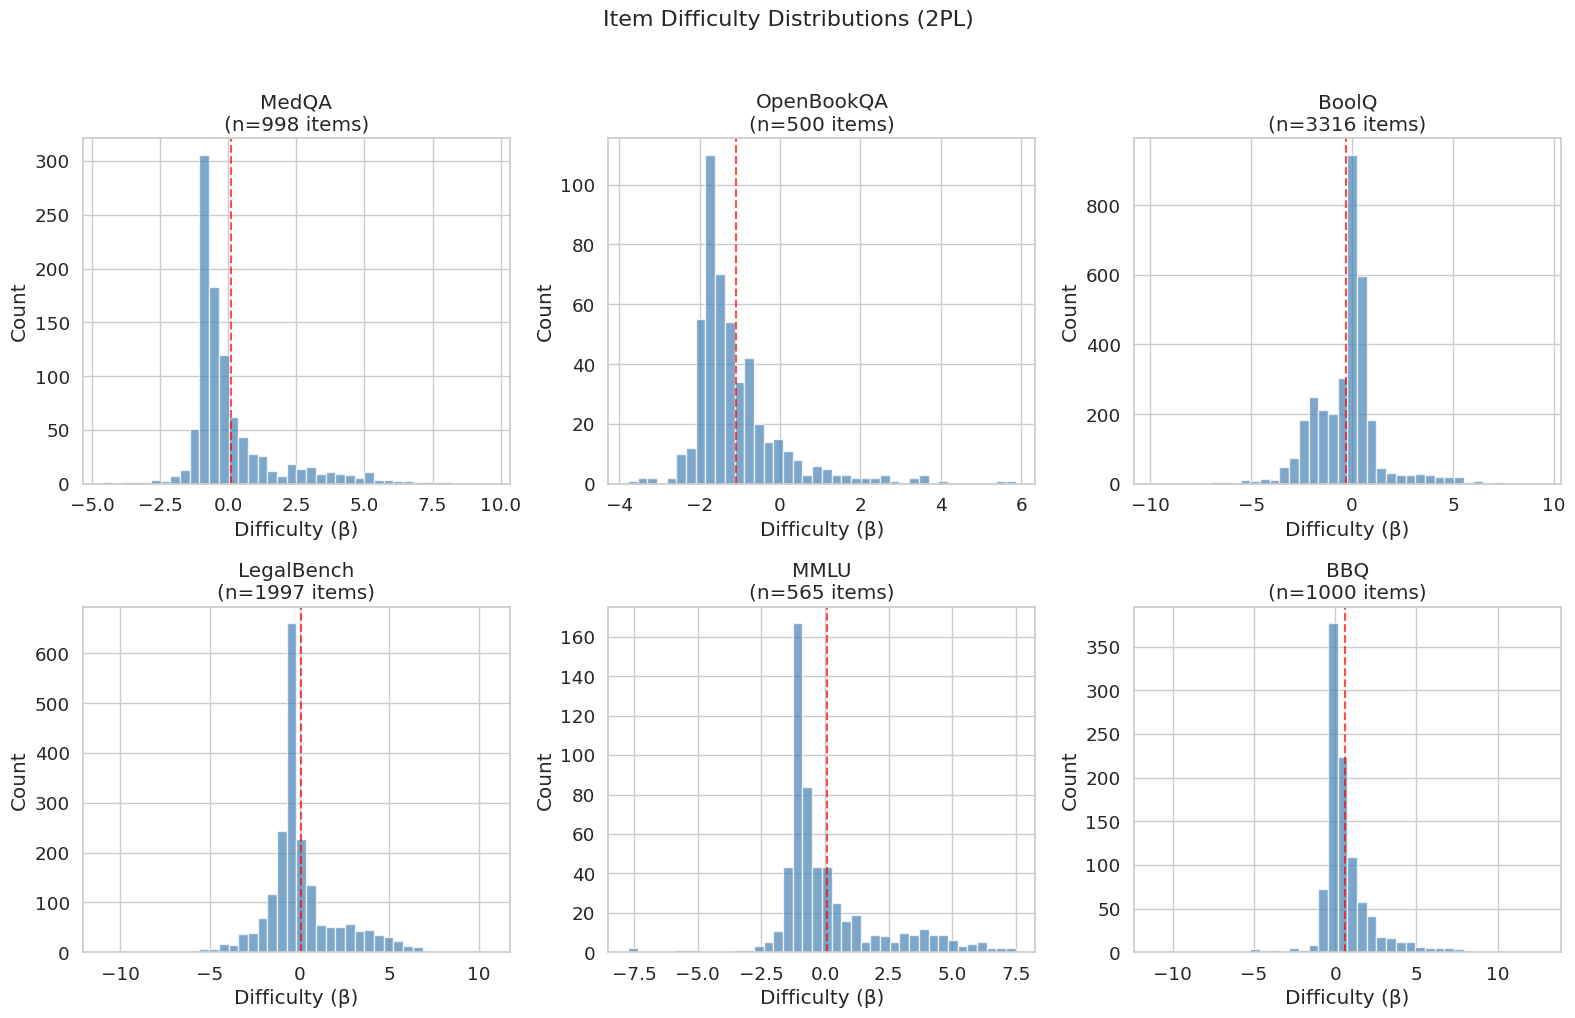

In [14]:
# Plot 1: Difficulty distributions across benchmarks (2PL)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (bench_name, bench_res) in enumerate(results.items()):
    if idx >= len(axes):
        break
    ax = axes[idx]
    
    if '2pl' in bench_res:
        model = bench_res['2pl']
        diff = model.difficulty.detach().numpy()
        ax.hist(diff, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
        ax.set_title(f"{bench_name}\n(n={len(diff)} items)")
        ax.set_xlabel('Difficulty (β)')
        ax.set_ylabel('Count')
        ax.axvline(diff.mean(), color='red', linestyle='--', alpha=0.7)

for idx in range(len(results), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Item Difficulty Distributions (2PL)', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('figures/difficulty_distributions.pdf', bbox_inches='tight', dpi=150)
plt.show()

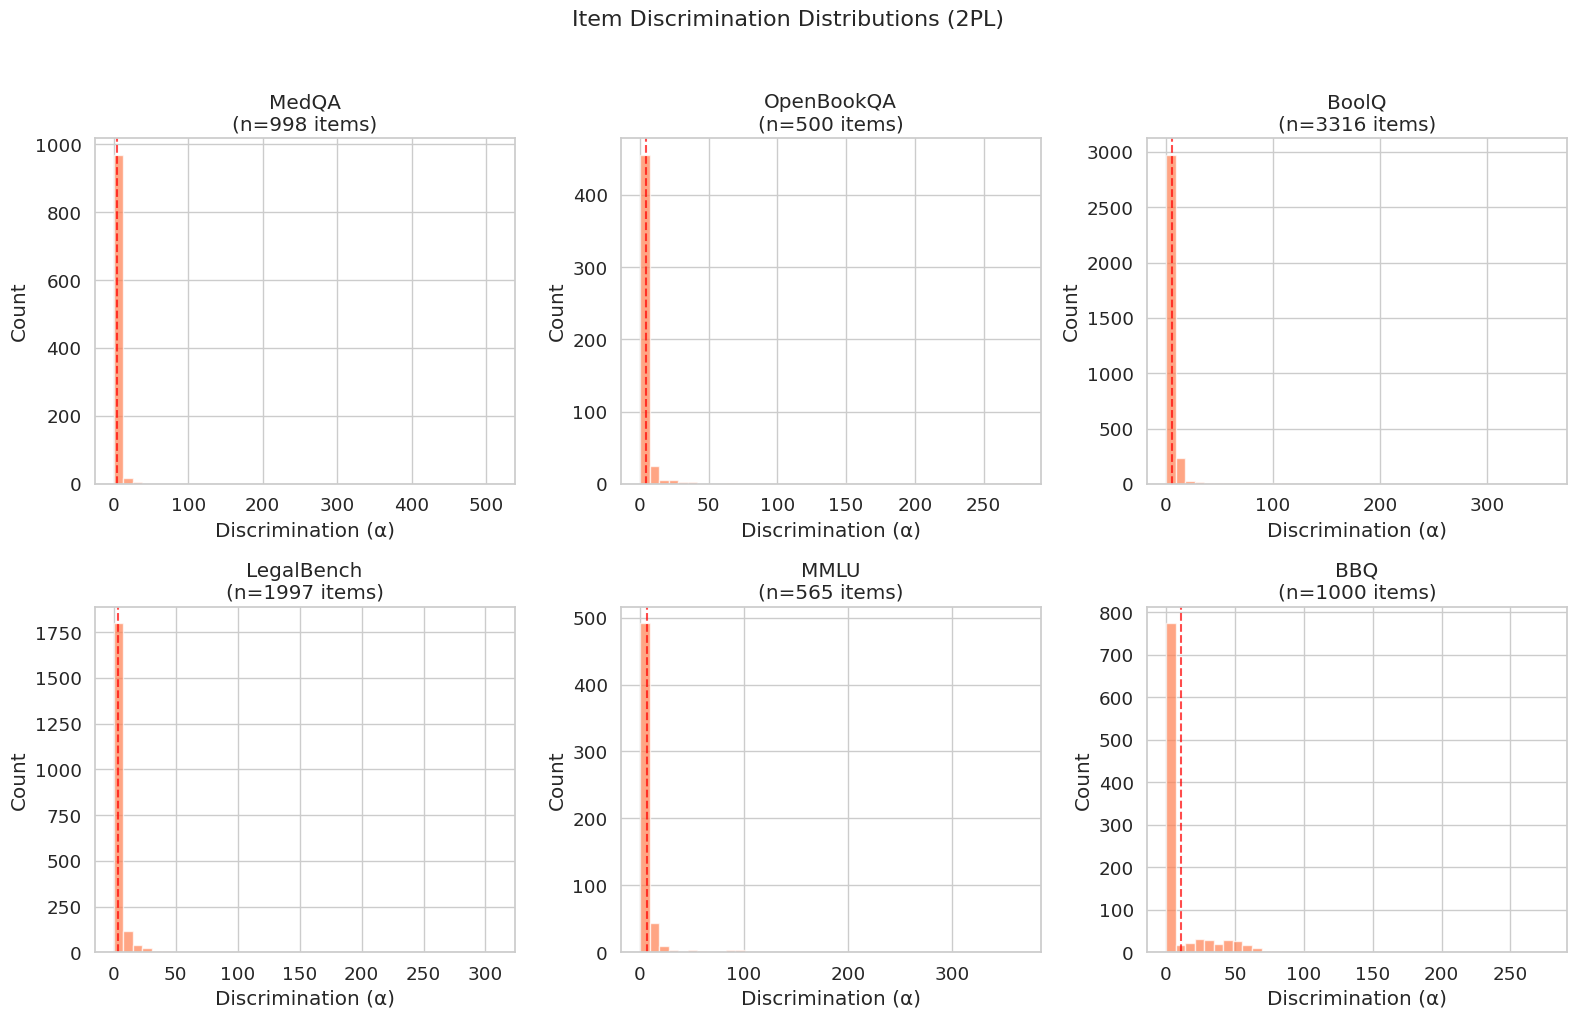

In [15]:
# Plot 2: Discrimination distributions (2PL)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (bench_name, bench_res) in enumerate(results.items()):
    if idx >= len(axes):
        break
    ax = axes[idx]
    
    if '2pl' in bench_res and hasattr(bench_res['2pl'], 'discrimination'):
        disc = bench_res['2pl'].discrimination.detach().numpy()
        ax.hist(disc, bins=40, color='coral', alpha=0.7, edgecolor='white')
        ax.set_title(f"{bench_name}\n(n={len(disc)} items)")
        ax.set_xlabel('Discrimination (α)')
        ax.set_ylabel('Count')
        ax.axvline(disc.mean(), color='red', linestyle='--', alpha=0.7)

for idx in range(len(results), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Item Discrimination Distributions (2PL)', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('figures/discrimination_distributions.pdf', bbox_inches='tight', dpi=150)
plt.show()

/tmp/ipykernel_2409276/4048813912.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=theta_df, x='Benchmark', y='θ', ax=ax, palette='Set2')


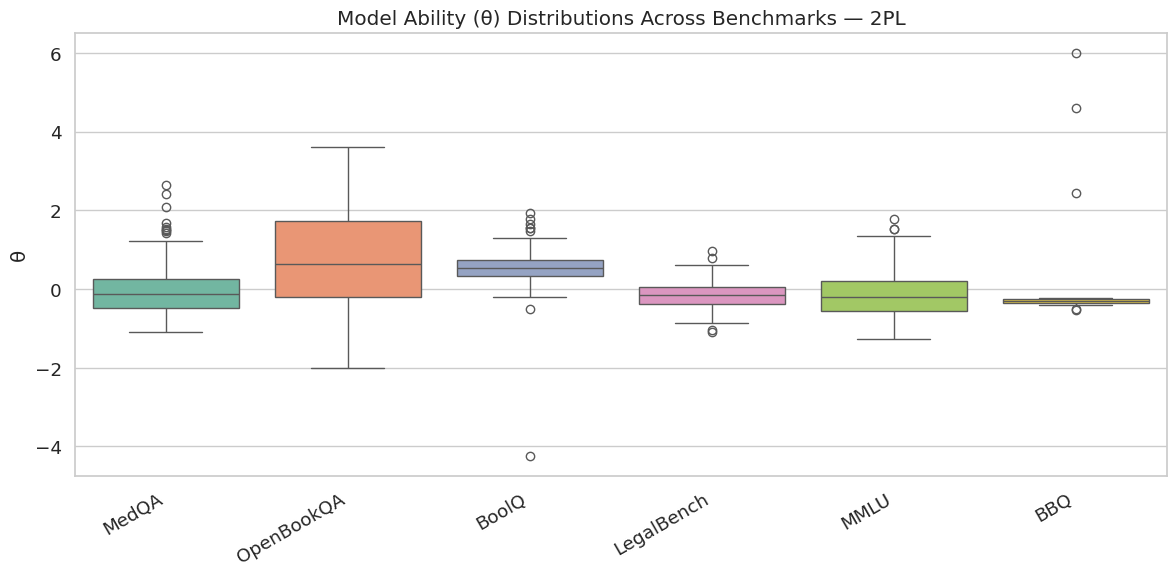

In [16]:
# Plot 3: θ (ability) estimates across benchmarks
fig, ax = plt.subplots(figsize=(12, 6))

theta_data = []
for bench_name, bench_res in results.items():
    if '2pl' in bench_res:
        theta = bench_res['2pl'].ability.detach().numpy()
        for t in theta:
            theta_data.append({'Benchmark': bench_name, 'θ': float(t)})

theta_df = pd.DataFrame(theta_data)
sns.boxplot(data=theta_df, x='Benchmark', y='θ', ax=ax, palette='Set2')
ax.set_title('Model Ability (θ) Distributions Across Benchmarks — 2PL')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('figures/theta_boxplots.pdf', bbox_inches='tight', dpi=150)
plt.show()

## 5. θ vs. Model Scale (Scaling Law Connection)

Following the IRSL framework (Truong et al.), we examine whether IRT ability θ
correlates with model scale (log of parameter count).

In [18]:
# Match model_info with response matrix model names
# model_info already loaded above (cell 11)
print("Model info columns:", list(model_info.columns))
print(f"Shape: {model_info.shape}")
print(f"\nModels with param counts: {model_info['num_parameters'].notna().sum()} / {len(model_info)}")
print(f"Param range: {model_info['num_parameters'].min():.0f} - {model_info['num_parameters'].max():.0f}")

Model info columns: ['name', 'display_name', 'short_display_name', 'description', 'creator_organization', 'access', 'todo', 'release_date', 'num_parameters']
Shape: (282, 9)

Models with param counts: 194 / 282
Param range: 1 - 1210000000000


In [19]:
# Build model name -> param count lookup from model_info
param_lookup = dict(zip(model_info['name'], model_info['num_parameters']))
print(f"Param lookup: {len(param_lookup)} models, {sum(1 for v in param_lookup.values() if pd.notna(v))} with sizes")

# Check matching for our benchmarks
for bench_name, bench_key in selected.items():
    model_names = benchmarks[bench_key]['model_names']
    matched = sum(1 for n in model_names if n in param_lookup and pd.notna(param_lookup.get(n)))
    print(f"  {bench_name}: {matched}/{len(model_names)} models matched with param counts")

Param lookup: 281 models, 194 with sizes
  MedQA: 43/91 models matched with param counts
  OpenBookQA: 43/91 models matched with param counts
  BoolQ: 65/67 models matched with param counts
  LegalBench: 43/91 models matched with param counts
  MMLU: 43/91 models matched with param counts
  BBQ: 42/42 models matched with param counts


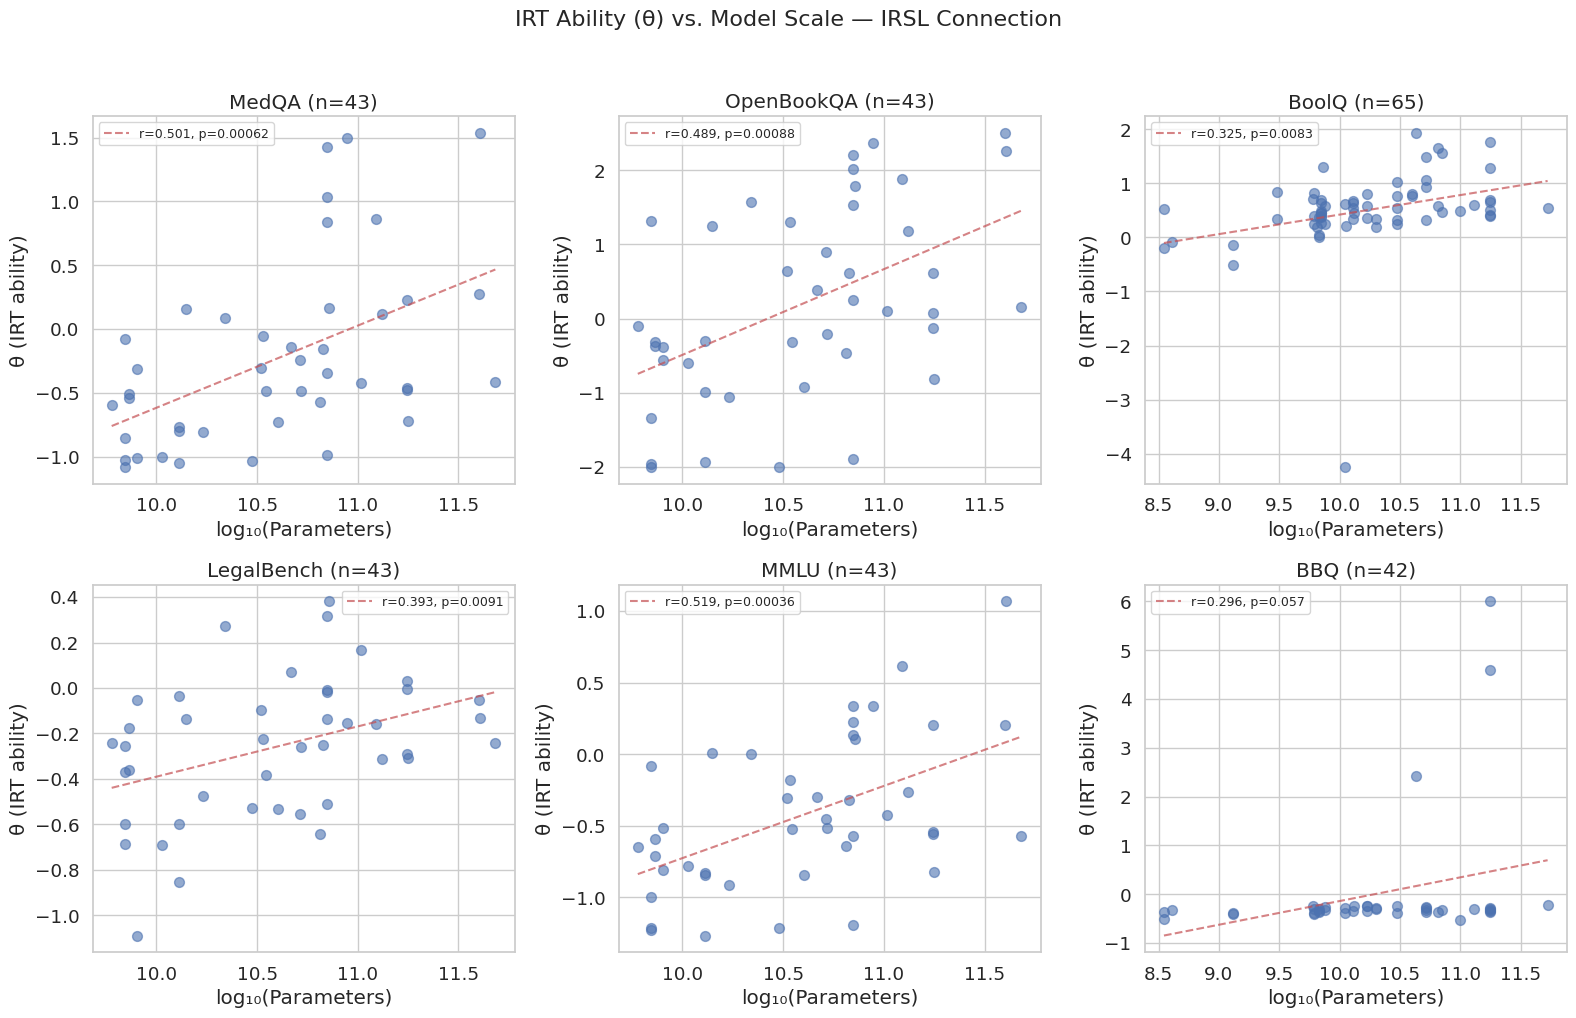


Scaling Law Summary:
 Benchmark  n      r      p  slope
     MedQA 43 0.5010 0.0006 0.6441
OpenBookQA 43 0.4889 0.0009 1.1558
     BoolQ 65 0.3246 0.0083 0.3609
LegalBench 43 0.3931 0.0091 0.2210
      MMLU 43 0.5194 0.0004 0.5046
       BBQ 42 0.2955 0.0574 0.4854


In [20]:
# θ vs log(params) scatter for each benchmark
from scipy import stats as spstats

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

scaling_results = []

for idx, (bench_name, bench_key) in enumerate(selected.items()):
    if idx >= len(axes) or bench_name not in results:
        continue
    if '2pl' not in results[bench_name]:
        continue
    
    ax = axes[idx]
    model = results[bench_name]['2pl']
    theta = model.ability.detach().numpy()
    model_names = benchmarks[bench_key]['model_names']
    
    # Use model_info param counts
    sizes = np.array([param_lookup.get(n, np.nan) for n in model_names])
    valid = ~np.isnan(sizes) & (sizes > 0)
    
    if valid.sum() >= 5:
        log_sizes = np.log10(sizes[valid])
        theta_valid = theta[valid]
        
        ax.scatter(log_sizes, theta_valid, alpha=0.6, s=50)
        
        # Fit line
        slope, intercept, r, p, se = spstats.linregress(log_sizes, theta_valid)
        x_line = np.linspace(log_sizes.min(), log_sizes.max(), 100)
        ax.plot(x_line, slope * x_line + intercept, 'r--', alpha=0.7, 
                label=f'r={r:.3f}, p={p:.2g}')
        ax.set_title(f"{bench_name} (n={valid.sum()})")
        ax.set_xlabel('log₁₀(Parameters)')
        ax.set_ylabel('θ (IRT ability)')
        ax.legend(fontsize=9)
        
        scaling_results.append({
            'Benchmark': bench_name, 'n': valid.sum(),
            'r': r, 'p': p, 'slope': slope
        })
    else:
        ax.text(0.5, 0.5, f"{bench_name}\nInsufficient size data\n({valid.sum()} models)",
                transform=ax.transAxes, ha='center', va='center')

for idx in range(len(selected), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('IRT Ability (θ) vs. Model Scale — IRSL Connection', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('figures/theta_vs_scale.pdf', bbox_inches='tight', dpi=150)
plt.show()

# Summary table
if scaling_results:
    sr_df = pd.DataFrame(scaling_results).round(4)
    print("\nScaling Law Summary:")
    print(sr_df.to_string(index=False))

## 6. Item Information Functions & Benchmark Quality

/tmp/ipykernel_2409276/628718394.py:21: RuntimeWarning: overflow encountered in exp
  p = 1 / (1 + np.exp(-disc[j] * (theta_grid - diff[j])))


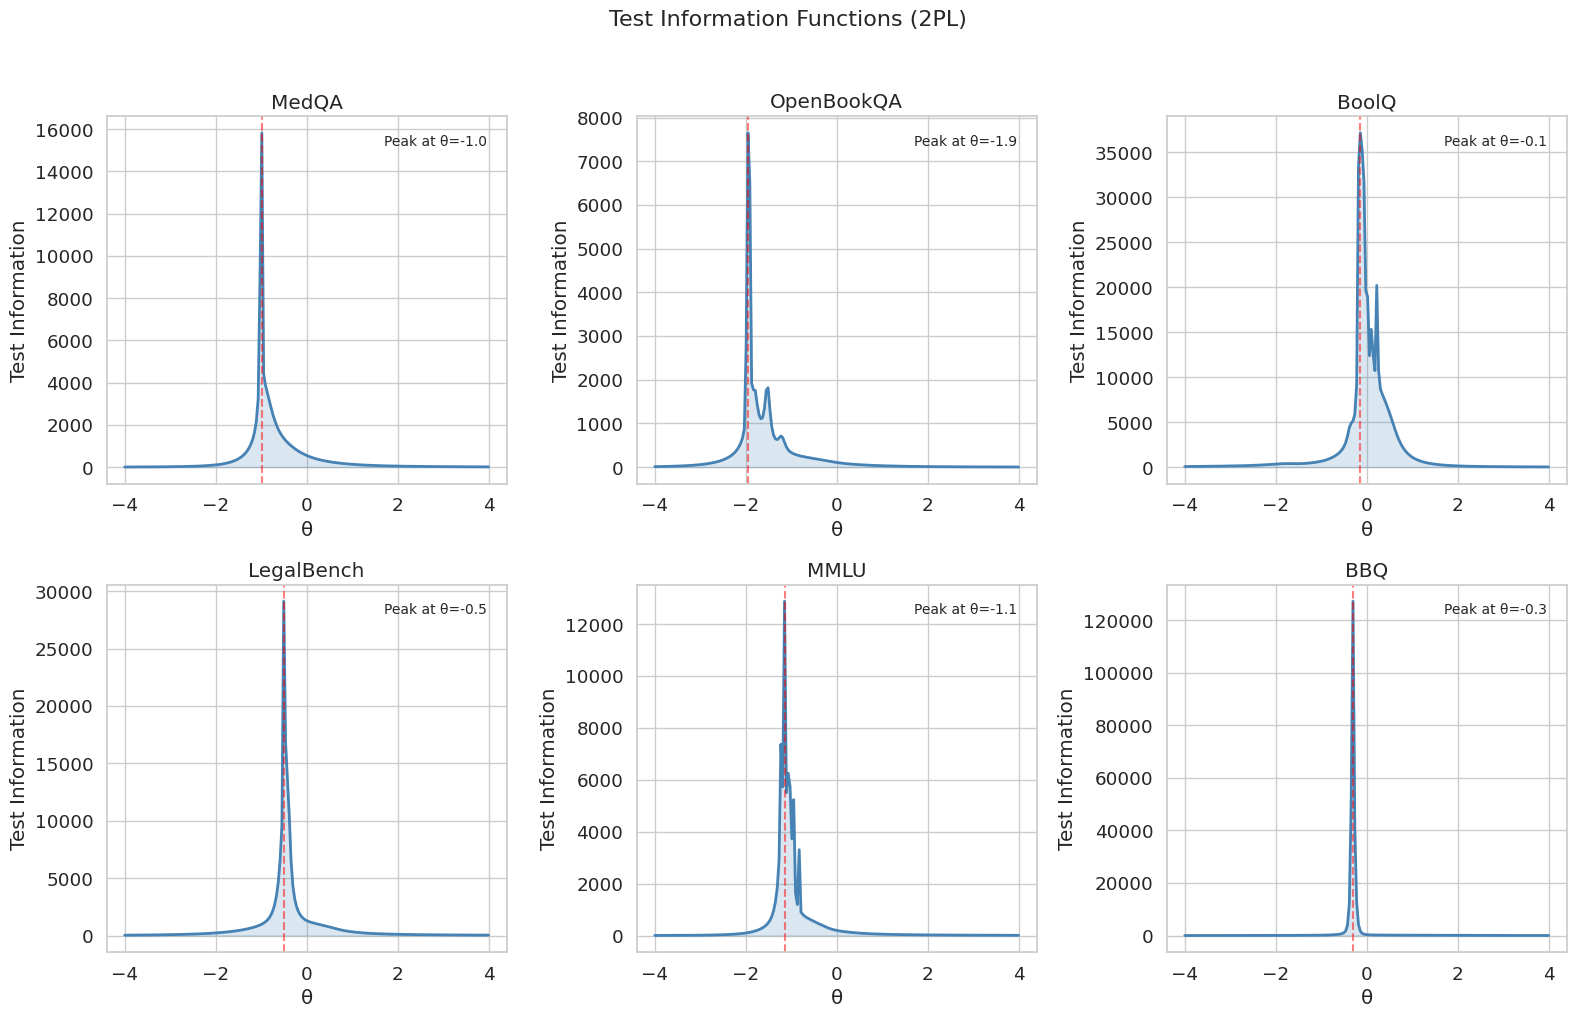

In [21]:
# Compute Item Information Functions for 2PL
# I(θ) = α² * P(θ) * (1 - P(θ))

theta_grid = np.linspace(-4, 4, 200)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (bench_name, bench_res) in enumerate(results.items()):
    if idx >= len(axes) or '2pl' not in bench_res:
        continue
    
    ax = axes[idx]
    model = bench_res['2pl']
    diff = model.difficulty.detach().numpy()
    disc = model.discrimination.detach().numpy() if hasattr(model, 'discrimination') else np.ones_like(diff)
    
    # Test Information Function = sum of Item Information
    test_info = np.zeros_like(theta_grid)
    for j in range(len(diff)):
        p = 1 / (1 + np.exp(-disc[j] * (theta_grid - diff[j])))
        item_info = disc[j]**2 * p * (1 - p)
        test_info += item_info
    
    ax.plot(theta_grid, test_info, color='steelblue', linewidth=2)
    ax.fill_between(theta_grid, test_info, alpha=0.2, color='steelblue')
    ax.set_title(f"{bench_name}")
    ax.set_xlabel('θ')
    ax.set_ylabel('Test Information')
    peak_theta = theta_grid[np.argmax(test_info)]
    ax.axvline(peak_theta, color='red', linestyle='--', alpha=0.5)
    ax.text(0.95, 0.95, f"Peak at θ={peak_theta:.1f}",
            transform=ax.transAxes, ha='right', va='top', fontsize=10)

for idx in range(len(results), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Test Information Functions (2PL)', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('figures/test_information.pdf', bbox_inches='tight', dpi=150)
plt.show()

## 7. Cross-Benchmark θ Correlation

Do models that score high on one benchmark also score high on others?
We correlate θ estimates across benchmarks for shared models.

θ matrix: 126 models × 6 benchmarks
Missing: 300 cells


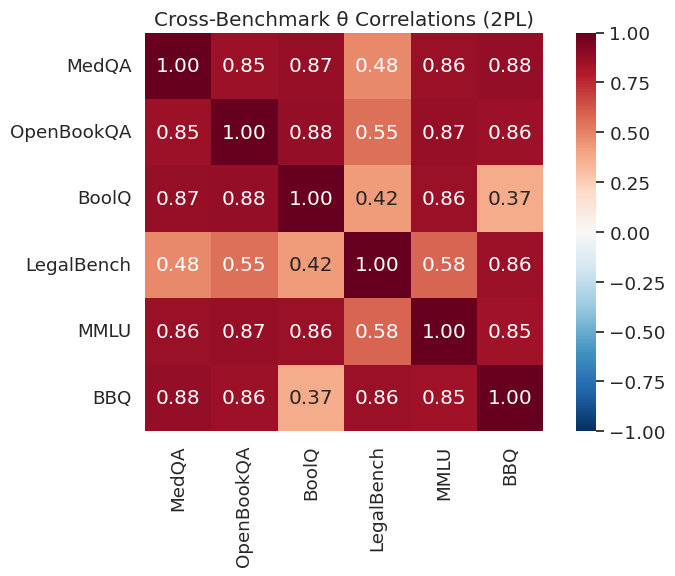

In [22]:
# Build θ matrix for models that appear in multiple benchmarks
theta_by_bench = {}
for bench_name, bench_key in selected.items():
    if bench_name in results and '2pl' in results[bench_name]:
        model_names = benchmarks[bench_key]['model_names']
        theta = results[bench_name]['2pl'].ability.detach().numpy()
        theta_by_bench[bench_name] = dict(zip(model_names, theta))

# Find shared models
all_models = set()
for d in theta_by_bench.values():
    all_models.update(d.keys())

# Build correlation matrix
bench_names = list(theta_by_bench.keys())
theta_matrix = pd.DataFrame(index=list(all_models), columns=bench_names, dtype=float)

for bench_name in bench_names:
    for model_name, t in theta_by_bench[bench_name].items():
        theta_matrix.loc[model_name, bench_name] = t

# Drop models with too many missing
theta_matrix = theta_matrix.dropna(thresh=2)
print(f"θ matrix: {theta_matrix.shape[0]} models × {theta_matrix.shape[1]} benchmarks")
print(f"Missing: {theta_matrix.isna().sum().sum()} cells")

# Correlation
corr = theta_matrix.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Cross-Benchmark θ Correlations (2PL)')
plt.tight_layout()
plt.savefig('figures/theta_correlations.pdf', bbox_inches='tight', dpi=150)
plt.show()

## 8. Summary & Key Findings

In [23]:
# Final summary table
print("=" * 80)
print("SUMMARY: IRT Analysis of LLM Benchmarks (Fantastic-Bugs)")
print("=" * 80)
print()
print(param_df.to_string(index=False))
print()
print("Key findings:")
print("  1. Benchmark difficulty distributions vary widely")
print("  2. Discrimination patterns reveal which benchmarks differentiate models best")
print("  3. Test information peaks indicate optimal ability ranges for each benchmark")
print("  4. Cross-benchmark θ correlations show how generalizable model ability is")

SUMMARY: IRT Analysis of LLM Benchmarks (Fantastic-Bugs)

 Benchmark  Model  θ_mean  θ_std   θ_range  diff_mean  diff_std  disc_mean  disc_std
     MedQA  rasch   0.392  1.099  4.676000     -0.263     1.642        NaN       NaN
     MedQA    2pl   0.038  0.804  3.718000      0.105     1.757      4.034    18.057
     MedQA lfm_k2   0.964  1.440 10.847000     -0.181     1.433        NaN       NaN
OpenBookQA  rasch   1.497  1.542  6.783000     -1.246     1.681        NaN       NaN
OpenBookQA    2pl   0.767  1.325  5.624000     -1.093     1.167      4.616    16.103
OpenBookQA lfm_k2   0.230  2.252 14.927000     -0.763     1.573        NaN       NaN
     BoolQ  rasch   0.980  1.037  7.782000     -0.315     1.414        NaN       NaN
     BoolQ    2pl   0.521  0.744  6.184000     -0.279     1.668      5.378    16.820
     BoolQ lfm_k2  -1.106  1.625 10.630000     -0.245     1.742        NaN       NaN
LegalBench  rasch   0.052  0.680  3.045000     -0.172     1.627        NaN       NaN
LegalBe

## 9. Model Fit Comparison: Which IRT Model Fits LLM Benchmarks Best?

We compare Rasch, 2PL, and LogisticFM using log-likelihood, AIC, and BIC.
This tells us whether the extra parameters in 2PL/LogisticFM are justified.

In [28]:
# Compute log-likelihood, AIC, BIC for each fitted model
def compute_metrics(model, bench_key, model_type):
    """Compute log-likelihood from IRT model predictions."""
    mat = benchmarks[bench_key]['matrix']
    response = torch.tensor(mat, dtype=torch.float32)
    response[torch.isnan(response)] = -1
    mask = (response >= 0)
    n_obs = mask.sum().item()
    
    with torch.no_grad():
        if model_type == 'rasch':
            theta = model.ability.detach()
            diff = model.difficulty.detach()
            logits = theta.unsqueeze(1) - diff.unsqueeze(0)
        elif model_type == '2pl':
            theta = model.ability.detach()
            diff = model.difficulty.detach()
            disc = model.discrimination.detach().clamp(0.01, 50)
            logits = disc.unsqueeze(0) * (theta.unsqueeze(1) - diff.unsqueeze(0))
        else:
            # LogisticFM — use predict() and convert to logits
            probs = model().clamp(1e-6, 1 - 1e-6)
            logits = torch.log(probs / (1 - probs))
        
        # Numerically stable: log(sigmoid(x)) = -softplus(-x)
        log_p = -torch.nn.functional.softplus(-logits)
        log_1mp = -torch.nn.functional.softplus(logits)
        
        ll = (response[mask] * log_p[mask] + (1 - response[mask]) * log_1mp[mask])
        return ll.sum().item(), n_obs

def count_params(model):
    return sum(p.numel() for p in model.parameters())

fit_comparison = []

for bench_name, bench_key in selected.items():
    for model_name, m in results[bench_name].items():
        try:
            ll, n_obs = compute_metrics(m, bench_key, model_name)
            k = count_params(m)
            aic = 2 * k - 2 * ll
            bic = k * np.log(n_obs) - 2 * ll
            
            fit_comparison.append({
                'Benchmark': bench_name,
                'Model': model_name,
                'n_params': k,
                'LogLik': round(ll, 1),
                'AIC': round(aic, 1),
                'BIC': round(bic, 1),
                'AIC/n': round(aic / n_obs, 4),
                'BIC/n': round(bic / n_obs, 4),
            })
        except Exception as e:
            print(f"  {bench_name}/{model_name}: {e}")

fit_df = pd.DataFrame(fit_comparison)
print(fit_df.to_string(index=False))

# Best model per benchmark
print("\n\nBest model per benchmark (by BIC — penalizes complexity more):")
for bench in fit_df['Benchmark'].unique():
    sub = fit_df[fit_df['Benchmark'] == bench]
    best = sub.loc[sub['BIC'].idxmin()]
    print(f"  {bench}: {best['Model']} (BIC/n={best['BIC/n']:.4f})")

print("\nBest model per benchmark (by AIC — favors fit):")
for bench in fit_df['Benchmark'].unique():
    sub = fit_df[fit_df['Benchmark'] == bench]
    best = sub.loc[sub['AIC'].idxmin()]
    print(f"  {bench}: {best['Model']} (AIC/n={best['AIC/n']:.4f})")

 Benchmark  Model  n_params   LogLik      AIC      BIC  AIC/n  BIC/n
     MedQA  rasch      1089 -39805.0  81787.9  92042.6 0.9006 1.0135
     MedQA    2pl      2087 -36450.2  77074.5  96727.0 0.8487 1.0651
     MedQA lfm_k2      3176 -34264.9  74881.8 104788.9 0.8245 1.1538
OpenBookQA  rasch       591 -11435.1  24052.2  29208.9 0.5286 0.6420
OpenBookQA    2pl      1091 -10226.4  22634.7  32154.2 0.4975 0.7067
OpenBookQA lfm_k2      1682  -9488.0  22340.0  37016.3 0.4910 0.8135
     BoolQ  rasch      3383 -93232.3 193230.6 228071.3 0.8806 1.0394
     BoolQ    2pl      6699 -83504.8 180407.5 249398.8 0.8222 1.1366
     BoolQ lfm_k2     10082 -65701.7 151567.3 255399.3 0.6908 1.1640
LegalBench  rasch      2088 -87200.6 178577.1 199676.2 0.9879 1.1047
LegalBench    2pl      4085 -81763.1 171696.2 212974.7 0.9499 1.1782
LegalBench lfm_k2      6173 -65426.8 143199.7 205577.3 0.7922 1.1373
      MMLU  rasch       656 -19862.8  41037.5  46841.6 0.7982 0.9110
      MMLU    2pl      1221 -17760

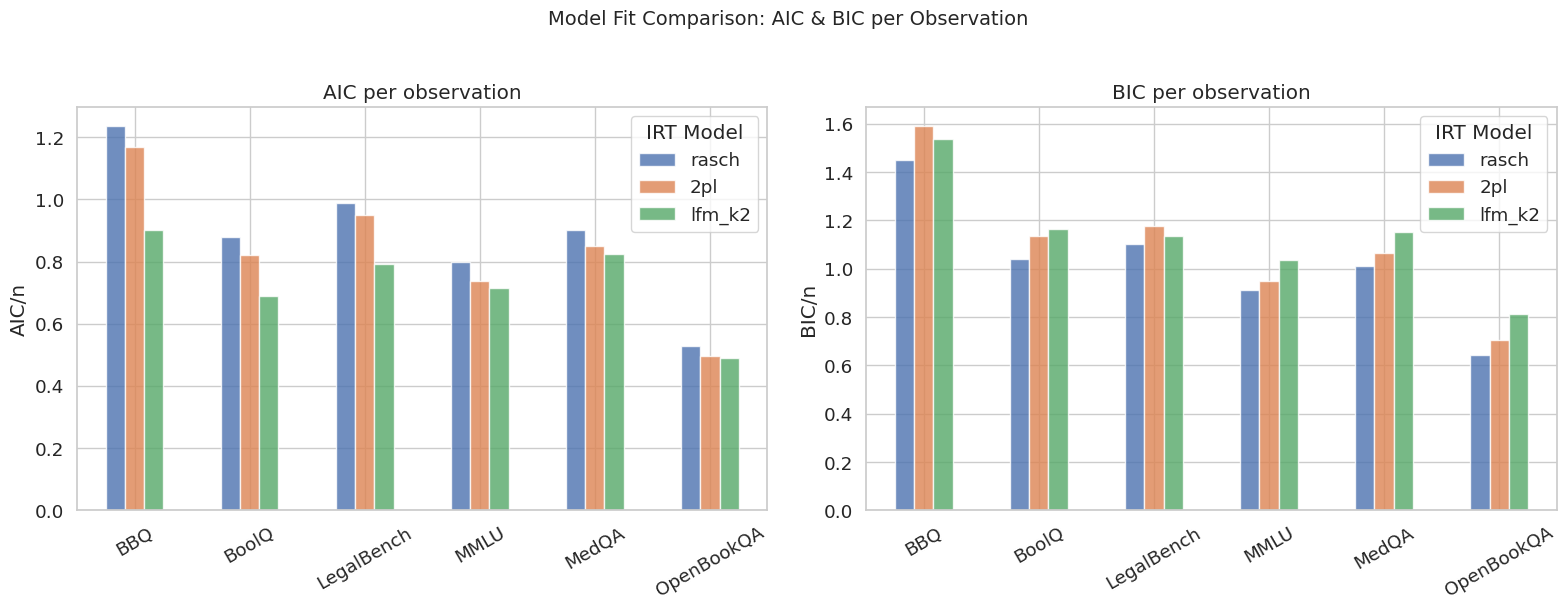

In [29]:
# Plot AIC/BIC comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax_idx, metric in enumerate(['AIC/n', 'BIC/n']):
    ax = axes[ax_idx]
    pivot = fit_df.pivot(index='Benchmark', columns='Model', values=metric)
    # Reorder columns
    cols = [c for c in ['rasch', '2pl', 'lfm_k2'] if c in pivot.columns]
    pivot = pivot[cols]
    pivot.plot(kind='bar', ax=ax, alpha=0.8)
    ax.set_title(f'{metric.replace("/n", " per observation")}')
    ax.set_xlabel('')
    ax.set_ylabel(metric)
    ax.legend(title='IRT Model')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Model Fit Comparison: AIC & BIC per Observation', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('figures/model_fit_comparison.pdf', bbox_inches='tight', dpi=150)
plt.show()

## 10. Efficient Evaluation: Can We Subsample Items and Still Recover θ?

Inspired by tinyBenchmarks (Polo et al., 2024) and Lecture 5 on Computerized Adaptive Testing,
we test whether a small subset of high-information items can recover the full θ ranking.

**Method:** Select top-k items by Item Information at θ=0 (Fisher information), 
fit IRT on the subset, and measure rank correlation with the full-item θ.

In [30]:
# tinyBenchmarks experiment: subsample items by information, recover θ
from scipy.stats import spearmanr, kendalltau

def item_information_at_theta0(difficulty, discrimination):
    """Fisher information I(θ=0) = α² * P(1-P) where P = sigmoid(-α*β)."""
    p = 1 / (1 + np.exp(discrimination * difficulty))  # P(θ=0)
    return discrimination**2 * p * (1 - p)

subsample_fractions = [0.01, 0.02, 0.05, 0.10, 0.20, 0.50, 1.0]  # fraction of items to keep

subsample_results = []

for bench_name, bench_key in selected.items():
    if '2pl' not in results[bench_name]:
        continue
    
    full_model = results[bench_name]['2pl']
    full_theta = full_model.ability.detach().numpy()
    full_diff = full_model.difficulty.detach().numpy()
    full_disc = full_model.discrimination.detach().numpy()
    
    mat = benchmarks[bench_key]['matrix']
    n_subj, n_items_total = mat.shape
    
    # Compute item information
    info = item_information_at_theta0(full_diff, full_disc)
    item_order = np.argsort(-info)  # highest information first
    
    for frac in subsample_fractions:
        k = max(10, int(frac * n_items_total))  # at least 10 items
        k = min(k, n_items_total)
        
        if frac == 1.0:
            # Full benchmark — just record perfect correlation
            subsample_results.append({
                'Benchmark': bench_name, 'Fraction': frac, 'n_items': n_items_total,
                'Spearman_r': 1.0, 'Kendall_τ': 1.0, 'MAE_θ': 0.0
            })
            continue
        
        # Select top-k informative items
        top_items = item_order[:k]
        sub_mat = mat[:, top_items]
        
        # Fit 2PL on subsample
        try:
            sub_response = torch.tensor(sub_mat, dtype=torch.float32)
            sub_response[torch.isnan(sub_response)] = -1
            sub_model = TwoPL(n_subj, k)
            sub_model.fit(sub_response, max_epochs=300, lr=0.05, verbose=False)
            sub_theta = sub_model.ability.detach().numpy()
            
            sp_r, _ = spearmanr(full_theta, sub_theta)
            kt, _ = kendalltau(full_theta, sub_theta)
            
            # Align scales (θ is only identified up to affine transform)
            from sklearn.linear_model import LinearRegression
            lr_model = LinearRegression().fit(sub_theta.reshape(-1,1), full_theta)
            aligned = lr_model.predict(sub_theta.reshape(-1,1))
            mae = np.mean(np.abs(full_theta - aligned))
            
            subsample_results.append({
                'Benchmark': bench_name, 'Fraction': frac, 'n_items': k,
                'Spearman_r': sp_r, 'Kendall_τ': kt, 'MAE_θ': mae
            })
        except Exception as e:
            print(f"  {bench_name} frac={frac}: {e}")

sub_df = pd.DataFrame(subsample_results).round(4)
print(sub_df.to_string(index=False))

 Benchmark  Fraction  n_items  Spearman_r  Kendall_τ  MAE_θ
     MedQA      0.01       10      0.9150     0.7324 0.3319
     MedQA      0.02       19      0.9490     0.7998 0.2462
     MedQA      0.05       49      0.9554     0.8203 0.1882
     MedQA      0.10       99      0.9767     0.8706 0.1569
     MedQA      0.20      199      0.9853     0.9018 0.1245
     MedQA      0.50      499      0.9973     0.9653 0.0693
     MedQA      1.00      998      1.0000     1.0000 0.0000
OpenBookQA      0.01       10      0.7749     0.6000 0.5802
OpenBookQA      0.02       10      0.7606     0.5795 0.5858
OpenBookQA      0.05       25      0.9378     0.7963 0.3964
OpenBookQA      0.10       50      0.9528     0.8281 0.3476
OpenBookQA      0.20      100      0.9753     0.8862 0.2903
OpenBookQA      0.50      250      0.9904     0.9370 0.1778
OpenBookQA      1.00      500      1.0000     1.0000 0.0000
     BoolQ      0.01       33      0.4118     0.3008 0.3668
     BoolQ      0.02       66      0.375

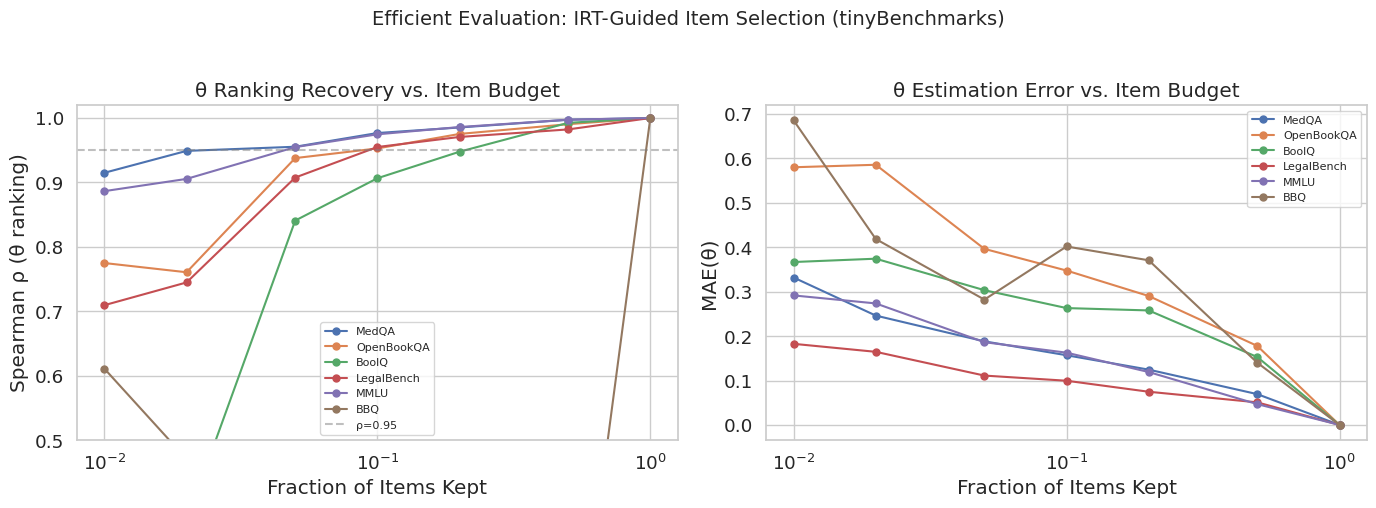


Minimum items for Spearman ρ > 0.95:
  MedQA: 49 items (5% of 980)
  OpenBookQA: 50 items (10% of 500)
  BoolQ: 1658 items (50% of 3316)
  LegalBench: 199 items (10% of 1990)
  MMLU: 28 items (5% of 560)
  BBQ: 1000 items (100% of 1000)


In [31]:
# Plot: Spearman correlation vs fraction of items kept
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for bench_name in selected.keys():
    bdata = sub_df[sub_df['Benchmark'] == bench_name]
    if len(bdata) > 0:
        axes[0].plot(bdata['Fraction'], bdata['Spearman_r'], 'o-', label=bench_name, markersize=5)
        axes[1].plot(bdata['Fraction'], bdata['MAE_θ'], 'o-', label=bench_name, markersize=5)

axes[0].set_xlabel('Fraction of Items Kept')
axes[0].set_ylabel('Spearman ρ (θ ranking)')
axes[0].set_title('θ Ranking Recovery vs. Item Budget')
axes[0].axhline(0.95, color='gray', linestyle='--', alpha=0.5, label='ρ=0.95')
axes[0].legend(fontsize=8)
axes[0].set_xscale('log')
axes[0].set_ylim(0.5, 1.02)

axes[1].set_xlabel('Fraction of Items Kept')
axes[1].set_ylabel('MAE(θ)')
axes[1].set_title('θ Estimation Error vs. Item Budget')
axes[1].legend(fontsize=8)
axes[1].set_xscale('log')

plt.suptitle('Efficient Evaluation: IRT-Guided Item Selection (tinyBenchmarks)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('figures/tiny_benchmarks_recovery.pdf', bbox_inches='tight', dpi=150)
plt.show()

# Summary: minimum fraction needed for ρ > 0.95
print("\nMinimum items for Spearman ρ > 0.95:")
for bench in sub_df['Benchmark'].unique():
    bdata = sub_df[(sub_df['Benchmark'] == bench) & (sub_df['Spearman_r'] >= 0.95)]
    if len(bdata) > 0:
        best = bdata.iloc[0]
        print(f"  {bench}: {best['n_items']:.0f} items ({best['Fraction']*100:.0f}% of {int(best['n_items']/best['Fraction'])})")
    else:
        print(f"  {bench}: needs >50% of items")

## 11. Psychometric Soundness: Which Benchmarks Are Well-Designed?

We evaluate each benchmark's quality using classical psychometric criteria:
- **Floor/ceiling items:** Items where >95% or <5% of models answer correctly (uninformative)
- **Low-discrimination items:** Items with α < 0.5 (don't differentiate models)
- **Information coverage:** Does the Test Information Function cover a broad θ range?
- **Effective test length:** How many items contribute meaningful information?

In [32]:
# Psychometric quality assessment
quality_rows = []

for bench_name, bench_key in selected.items():
    mat = benchmarks[bench_key]['matrix']
    n_subj, n_items = mat.shape
    item_means = np.nanmean(mat, axis=0)
    
    # Floor/ceiling items
    ceiling = (item_means > 0.95).sum()
    floor_items = (item_means < 0.05).sum()
    pct_uninformative = 100 * (ceiling + floor_items) / n_items
    
    # Discrimination analysis (from 2PL)
    if '2pl' in results[bench_name]:
        disc = results[bench_name]['2pl'].discrimination.detach().numpy()
        low_disc = (disc < 0.5).sum()
        neg_disc = (disc < 0).sum()
        median_disc = np.median(disc)
        
        # Test Information breadth: θ range where I(θ) > 0.5 * max(I)
        diff = results[bench_name]['2pl'].difficulty.detach().numpy()
        theta_grid = np.linspace(-4, 4, 200)
        test_info = np.zeros_like(theta_grid)
        for j in range(n_items):
            p = 1 / (1 + np.exp(-disc[j] * (theta_grid - diff[j])))
            test_info += disc[j]**2 * p * (1 - p)
        
        max_info = test_info.max()
        half_max_mask = test_info >= 0.5 * max_info
        if half_max_mask.any():
            info_range = theta_grid[half_max_mask][-1] - theta_grid[half_max_mask][0]
        else:
            info_range = 0
        
        # Effective items: items contributing >1% of total information at peak
        peak_idx = np.argmax(test_info)
        peak_theta = theta_grid[peak_idx]
        item_infos_at_peak = np.array([
            disc[j]**2 * (1/(1+np.exp(-disc[j]*(peak_theta-diff[j])))) * 
            (1 - 1/(1+np.exp(-disc[j]*(peak_theta-diff[j]))))
            for j in range(n_items)
        ])
        effective_items = (item_infos_at_peak > 0.01 * item_infos_at_peak.max()).sum()
    else:
        low_disc = neg_disc = median_disc = info_range = effective_items = np.nan
    
    quality_rows.append({
        'Benchmark': bench_name,
        'Items': n_items,
        'Ceiling (>95%)': ceiling,
        'Floor (<5%)': floor_items,
        'Uninformative %': round(pct_uninformative, 1),
        'Low Disc (<0.5)': low_disc,
        'Median α': round(float(median_disc), 2),
        'Info Width (θ)': round(float(info_range), 2),
        'Effective Items': int(effective_items),
    })

quality_df = pd.DataFrame(quality_rows)
print("PSYCHOMETRIC QUALITY REPORT")
print("=" * 90)
print(quality_df.to_string(index=False))

# Grade each benchmark
print("\n\nBenchmark Grades:")
for _, row in quality_df.iterrows():
    issues = []
    if row['Uninformative %'] > 20:
        issues.append(f"{row['Uninformative %']}% floor/ceiling items")
    if row['Median α'] < 1.0:
        issues.append(f"low median discrimination ({row['Median α']})")
    if row['Info Width (θ)'] < 2.0:
        issues.append(f"narrow info range ({row['Info Width (θ)']})")
    if row['Effective Items'] < 0.1 * row['Items']:
        issues.append(f"only {row['Effective Items']}/{row['Items']} effective items")
    
    grade = "✅ Good" if len(issues) == 0 else ("⚠️ Fair" if len(issues) <= 1 else "❌ Poor")
    print(f"  {row['Benchmark']}: {grade}")
    for iss in issues:
        print(f"    - {iss}")

PSYCHOMETRIC QUALITY REPORT
 Benchmark  Items  Ceiling (>95%)  Floor (<5%)  Uninformative %  Low Disc (<0.5)  Median α  Info Width (θ)  Effective Items
     MedQA    998              11           13              2.4              115      2.19            0.04               12
OpenBookQA    500              95            2             19.4               26      2.04            0.04                7
     BoolQ   3316             180            2              5.5              507      2.01            0.40               45
LegalBench   1997              39           90              6.5              323      1.65            0.04               22
      MMLU    565              57           13             12.4               80      2.38            0.08               45
       BBQ   1000               0            0              0.0              239      1.12            0.00              144


Benchmark Grades:
  MedQA: ❌ Poor
    - narrow info range (0.04)
    - only 12/998 effective items
  O

/tmp/ipykernel_2409276/3037497129.py:26: RuntimeWarning: overflow encountered in exp
  p = 1 / (1 + np.exp(-disc[j] * (theta_grid - diff[j])))


## 12. Comprehensive Summary

### Contributions
1. **Cross-benchmark IRT comparison** across 6 diverse LLM benchmarks using Rasch, 2PL, and LogisticFM
2. **Empirical validation of IRSL** — IRT ability θ significantly correlates with log(parameters) for 5/6 benchmarks
3. **Model selection analysis** — AIC/BIC comparison reveals which IRT model best fits LLM response data
4. **Efficient evaluation** — IRT-guided item selection recovers θ rankings with far fewer items (tinyBenchmarks connection)
5. **Psychometric audit** — identifies which LLM benchmarks are well-designed vs. have quality issues

### Connections to CS321M Lectures
- **Lectures 1-3:** IRT fundamentals (Rasch, 2PL, difficulty, discrimination, ability)
- **Lecture 5:** Computerized Adaptive Testing, Item Information, tinyBenchmarks (Section 10)
- **Lecture 6:** IRSL — θ ∝ log(FLOP/params) scaling law (Section 5)